In [1]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("Enable GPU (Runtime → Change runtime type → T4 GPU)")

Torch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


In [2]:
!git clone https://github.com/raghavtripathii/docshield-ai.git

%cd docshield-ai

Cloning into 'docshield-ai'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 290 (delta 22), reused 38 (delta 11), pack-reused 240 (from 1)
Receiving objects: 100% (290/290), 4.36 MiB | 23.90 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/docshield-ai


In [3]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00


In [4]:
import os
import json
import random
import numpy as np
import torch

from datasets import load_dataset

from transformers import (
    LayoutLMv3Processor,
    LayoutLMv3ForTokenClassification,
    TrainingArguments,
)

from src.dataset import FUNSDDataset
from src.robust_dataset import RobustDataset
from src.augmentation import AugmentationPipeline
from src.train_robust import RobustTrainer

from configs.robust_training import *

In [5]:
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [6]:
dataset = load_dataset("nielsr/funsd")

train_split = dataset["train"]

test_split = dataset["test"]

print(train_split)

print(test_split)

README.md:   0%|          | 0.00/755 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.38MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
    num_rows: 149
})
Dataset({
    features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
    num_rows: 50
})


In [7]:
processor = LayoutLMv3Processor.from_pretrained(
    MODEL_NAME,
    apply_ocr=False,
)

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [8]:
train_dataset = FUNSDDataset(
    train_split,
    processor,
)

eval_dataset = FUNSDDataset(
    test_split,
    processor,
)

In [9]:
pipeline = AugmentationPipeline(
    corruption_probability=0.5,
    seed=SEED,
)

In [10]:
robust_train_dataset = RobustDataset(
    train_dataset,
    augmentation_pipeline=pipeline,
)

In [13]:
from transformers import LayoutLMv3ForTokenClassification

from src.labels import (
    get_label_list,
    build_label_maps,
)

label_list = get_label_list(dataset)

id2label, label2id = build_label_maps(
    label_list
)

num_labels = len(label_list)

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

print(model.__class__.__name__)
print("Labels:", num_labels)
print(label_list)

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LayoutLMv3ForTokenClassification
Labels: 7
['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER']


In [15]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,

    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    num_train_epochs=NUM_EPOCHS,

    weight_decay=WEIGHT_DECAY,

    warmup_ratio=WARMUP_RATIO,

    logging_steps=LOGGING_STEPS,

    save_strategy=SAVE_STRATEGY,

    eval_strategy=EVALUATION_STRATEGY,

    save_total_limit=2,

    load_best_model_at_end=True,

    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=SEED,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
robust_trainer = RobustTrainer(
    model=model,
    train_dataset=robust_train_dataset,
    eval_dataset=eval_dataset,
    training_args=training_args,
)

trainer = robust_trainer.build()

trainer

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.463570,0.720569
2,0.766299,0.670608
3,0.571034,0.564514
4,0.388841,0.569190
5,0.258574,0.599628


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.6519012006123861, metrics={'train_runtime': 311.3081, 'train_samples_per_second': 2.393, 'train_steps_per_second': 1.205, 'total_flos': 196385980707840.0, 'train_loss': 0.6519012006123861, 'epoch': 5.0})

In [18]:
metrics = trainer.evaluate()

metrics

Training Loss,Validation Loss,Epoch
0.258574,0.564514,5


{'eval_loss': 0.5645138025283813}

In [19]:
import os
import json

os.makedirs("results", exist_ok=True)

with open(
    "results/evaluation_metrics.json",
    "w",
) as f:
    json.dump(
        metrics,
        f,
        indent=4,
    )

print(metrics)

{'eval_loss': 0.5645138025283813}


In [20]:
trainer.save_model("outputs/robust_layoutlmv3")

processor.save_pretrained(
    "outputs/robust_layoutlmv3"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['outputs/robust_layoutlmv3/processor_config.json']

In [21]:
import pandas as pd

history = trainer.state.log_history

history = pd.DataFrame(history)

history.to_csv(
    "results/training_history.csv",
    index=False,
)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.463570,18.475376,0.000048,0.666667,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.000000,75,0.720569,2.9700,16.835,8.417,NaN,NaN,NaN,NaN,NaN
2,0.894530,15.313905,0.000041,1.333333,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.766299,17.141756,0.000034,2.000000,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.000000,150,0.670608,2.9783,16.788,8.394,NaN,NaN,NaN,NaN,NaN


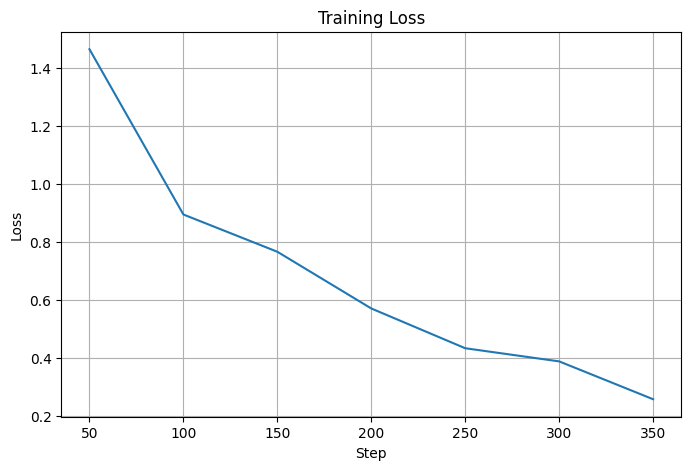

In [22]:
import matplotlib.pyplot as plt

loss_history = history[
    history["loss"].notna()
]

plt.figure(figsize=(8,5))

plt.plot(
    loss_history["step"],
    loss_history["loss"],
)

plt.xlabel("Step")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid()

plt.savefig(
    "results/training_curve.png",
    dpi=300,
)

plt.show()

In [23]:
import os

for root, _, files in os.walk("."):

    for file in files:

        if file.endswith(
            (
                ".json",
                ".csv",
                ".png",
                ".safetensors",
            )
        ):
            print(
                os.path.join(
                    root,
                    file,
                )
            )

./outputs/robust_layoutlmv3/processor_config.json
./outputs/robust_layoutlmv3/model.safetensors
./outputs/robust_layoutlmv3/config.json
./outputs/robust_layoutlmv3/tokenizer.json
./outputs/robust_layoutlmv3/tokenizer_config.json
./outputs/robust_layoutlmv3/checkpoint-375/trainer_state.json
./outputs/robust_layoutlmv3/checkpoint-375/model.safetensors
./outputs/robust_layoutlmv3/checkpoint-375/config.json
./outputs/robust_layoutlmv3/checkpoint-225/trainer_state.json
./outputs/robust_layoutlmv3/checkpoint-225/model.safetensors
./outputs/robust_layoutlmv3/checkpoint-225/config.json
./results/training_curve.png
./results/training_history.csv
./results/baseline_per_class.json
./results/baseline_metrics.json
./results/evaluation_metrics.json
./configs/baseline.json
